In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import os

LOAD DATA

In [ ]:
path = "/content/drive/MyDrive/Sensor_DL/final_data"

X_train = np.load(os.path.join(path, "X_train.npy"))
y_train = np.load(os.path.join(path, "y_train.npy"))

X_val = np.load(os.path.join(path, "X_val.npy"))
y_val = np.load(os.path.join(path, "y_val.npy"))

X_test = np.load(os.path.join(path, "X_test.npy"))
y_test = np.load(os.path.join(path, "y_test.npy"))

# Fix labels: Decrementing labels by 1 to make them 0-indexed.
# This is necessary because deep learning frameworks like TensorFlow/Keras
# often expect class labels to start from 0 for functions like sparse_categorical_crossentropy.
y_train -= 1
y_val -= 1
y_test -= 1

num_classes = len(np.unique(y_train))

CLASS WEIGHTS

In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))


MODEL

In [ ]:
model = Sequential([
    Input(shape=(50, X_train.shape[2])),

    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


CALLBACKS

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Sensor_DL/best_final_2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

TRAIN

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0967 - loss: 2.8833
Epoch 1: val_accuracy improved from None to 0.15148, saving model to /content/drive/MyDrive/Sensor_DL/best_final_2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Sensor_DL/best_final_2.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.1099 - loss: 2.7402 - val_accuracy: 0.1515 - val_loss: 2.4618
Epoch 2/30
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1722 - loss: 2.4543
Epoch 2: val_accuracy improved from 0.15148 to 0.23593, saving model to /content/drive/MyDrive/Sensor_DL/best_final_2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Sensor_DL/best_final_2.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1866 - loss: 2.3849 - val_accuracy: 0.2359 - val_loss: 2.3634
Epoch 3/30
95/97 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2499 - loss: 2.1602
Epoch 3: val_accuracy improved from 0.23593 to 0.33667, saving model to /content/drive/MyDriv

TEST

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(" FINAL Test Accuracy:", acc)
model.save("/content/drive/MyDrive/Sensor_DL/final_model_2.keras")

214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9553 - loss: 0.1190
✅ FINAL Test Accuracy: 0.955265462398529


214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


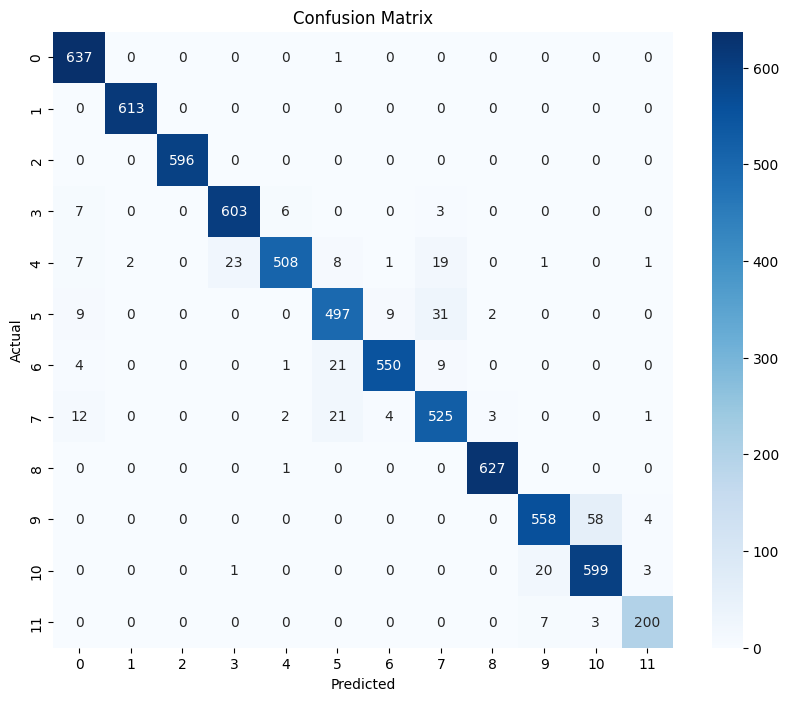


Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       638
           1       1.00      1.00      1.00       613
           2       1.00      1.00      1.00       596
           3       0.96      0.97      0.97       619
           4       0.98      0.89      0.93       570
           5       0.91      0.91      0.91       548
           6       0.98      0.94      0.96       585
           7       0.89      0.92      0.91       568
           8       0.99      1.00      1.00       628
           9       0.95      0.90      0.93       620
          10       0.91      0.96      0.93       623
          11       0.96      0.95      0.95       210

    accuracy                           0.96      6818
   macro avg       0.96      0.95      0.95      6818
weighted avg       0.96      0.96      0.96      6818



In [ ]:

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))